In [19]:
from attention_predict.dataset import CElegansDataset, CElegansDatasetPlus
from attention_predict.unet import UNet
from copy import deepcopy
from tqdm import tqdm
import json
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
def aggregate_loss(targets, outputs, recorded_neuron_indices, behavior_indices):
    """ Compute MSE loss for each batch separately on the reconstruction of recorded
    neural and behavioral activities.
    """
    # both `targets` and `outputs` have shape (batch_size, num_inputs, window_size)
    batch_size = targets.shape[0]
    mse = torch.nn.MSELoss()
    loss = 0
    for n in range(batch_size):
        # for now assume neuron indices are 0 and 1 (AVA and MC)
        indices = recorded_neuron_indices[n] + behavior_indices
        loss += mse(targets[n, indices, :], outputs[n, indices, :])

    return loss

In [33]:
def get_mask_indices(recorded_neuron_indices, num_inputs, num_neurons):

    mask_indices = {}
    all_indices = list(range(num_inputs))
    neuron_indices = list(range(num_neurons))

    for n in recorded_neuron_indices.keys():
        # randomly mask out one if all neurons are recored
        if len(recorded_neuron_indices[n]) == 2:
            neuron_index = np.random.choice(recorded_neuron_indices[n])
        else:
            options = list(set(neuron_indices) - set(recorded_neuron_indices[n]))
            neuron_index = np.random.choice(options)
            
        # For now we disallow simultaneous masking of AVA-velocity or MC-pumping pairs
        if neuron_index == 0: # masking AVA
            behavior_index = 3
        elif neuron_index == 1:
            behavior_index = 2
        # behavior_index = np.random.choice(list(set(all_indices) -
        #                                        set(recorded_neuron_indices[n])))
        mask_indices[n] = [neuron_index, behavior_index]

    return mask_indices

In [34]:
def get_recorded_neuron_indices(targets, num_neurons):

    batch_size = targets.shape[0]
    recorded_neuron_indices = {}

    for n in range(batch_size):
        recorded_neuron_indices[n] = [
            i for i in range(num_neurons)
            if (torch.max(targets[n, i, :]).item() != 0
            and torch.min(targets[n, i, :]).item() != 0)
        ]
    return recorded_neuron_indices

In [35]:
### breaking down the training loop ###

base = '/home/alicia/notebook/alicia/attention_predict'

device = "cuda:2"
window_size = 400
window_stride = 1
ds_name = 'AVA_MC_all_test' # try a small one
batch_size = 32

num_neurons = 2
depth = 5
in_channels = np.load(f'{base}/data/{ds_name}.npy').shape[1]
out_channels = in_channels
unet_dim = 1
num_iterations = 1_000_000
num_epochs = 1
learning_rate = 1e-4
random_seed = 1912 # Alan Turing's birthday :)

# loading in datasets

training_dataset = CElegansDatasetPlus(
    f'{base}/data/{ds_name}.npy',
    window_stride=window_stride,
    window_size=window_size,
    device=device,
    slices=slice(0, 1600)
)

# declaring dataloaders
training_dataloader = torch.utils.data.DataLoader(
    training_dataset,
    batch_size=batch_size,
    shuffle=True)

# declaring the model
model = UNet(
        depth, in_channels, out_channels, unet_dim=unet_dim
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
num_inputs = next(iter(training_dataloader))[0].shape[1]
num_batches = len(training_dataloader)

# Assume all behaviors are always recorded
behavior_indices = list(range(num_neurons, num_inputs))

In [68]:
# Set random seed for reproducible masking
np.random.seed(1912)

for n_epoch in tqdm(range(num_epochs)):

    loss_average = 0

    for n_iter, (inputs, worm, start_frame, end_frame) in enumerate(training_dataloader):

        if n_iter == num_iterations:
            break

        targets = deepcopy(inputs)
        x = deepcopy(inputs)
        # Find which neurons are recorded per sample in a batch
        recorded_neuron_indices = get_recorded_neuron_indices(targets, num_neurons)   
        # Apply masking to each sample according to which neurons are recorded
        mask_indices = get_mask_indices(recorded_neuron_indices, num_inputs, num_neurons)
        
        for n in mask_indices.keys():
            x[n, mask_indices[n], :] = 0

        optimizer.zero_grad()
        outputs = model(x)
        # Compute MSE loss for each sample and sum up
        loss = aggregate_loss(targets, outputs, recorded_neuron_indices,
                              behavior_indices)
        loss.backward()
        optimizer.step()
        loss_average += loss.item()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:06<00:00,  6.55s/it]


sample: 7


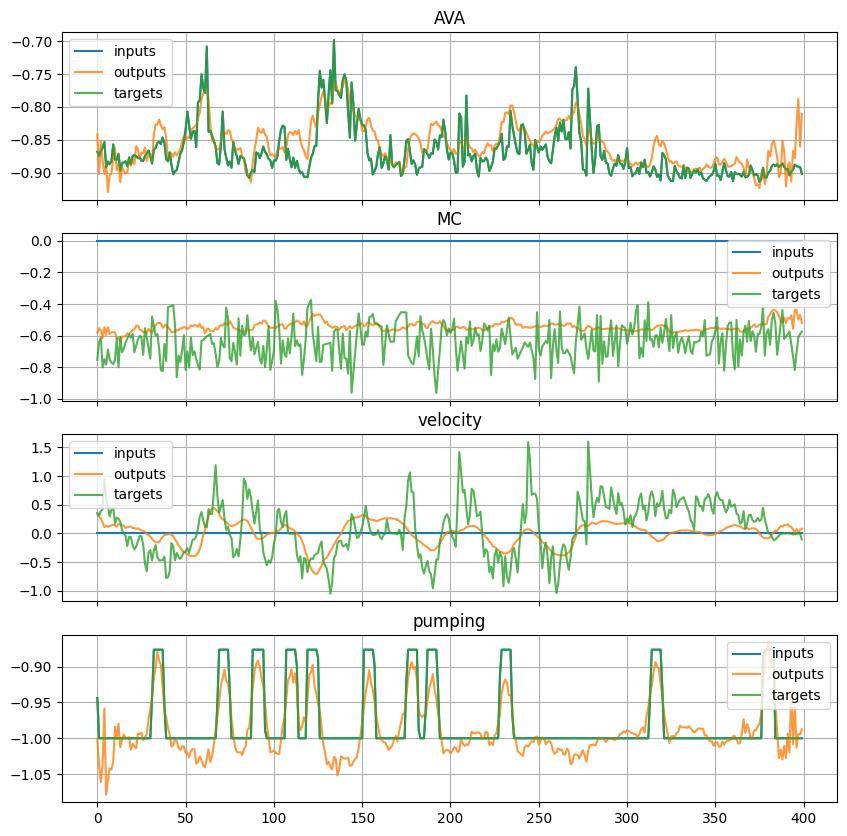

In [69]:
sample = np.random.choice(list(range(32)))
#sample = 18
variables = {0: 'AVA', 1: 'MC', 2: 'velocity', 3: 'pumping'}

num_variables = len(variables)

fig, axs = plt.subplots(num_variables, 1, figsize=(10, 10), sharex=True)
print(f'sample: {sample}')

for i in range(num_variables):
    axs[i].plot(
        x[sample][i, :].cpu().detach().numpy(),
        label='inputs'
    )
    axs[i].plot(
        outputs[sample][i, :].cpu().detach().numpy(),
        label='outputs',
        alpha=0.8
    )
    axs[i].plot(
        targets[sample][i, :].cpu().detach().numpy(),
        label='targets',
        alpha=0.8
    )
    axs[i].set_title(
        variables[i])
    axs[i].grid(True)
    axs[i].legend()

In [61]:
np.unique(x.cpu().detach().numpy())

array([0.], dtype=float32)

In [49]:
#np.unique(outputs.cpu().detach().numpy())

In [53]:
x.shape

torch.Size([32, 4, 400])